In [ ]:
import json
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
import torch

In [ ]:
with open("/content/course_data (2).json", encoding="utf-8") as f:
  data = json.load(f)

df = pd.DataFrame(data).T
df.head()

,course_title,num_ratings,useful,easy,liked,reviews
CS 115,Introduction to Computer Science 1,2111,21%,10%,23%,[{'review_text': 'go to office hours and pract...
MATH 135,Algebra for Honours Mathematics,1186,84%,41%,78%,"[{'review_text': 'Welcome to Waterloo Math.', ..."
ECON 101,Introduction to Microeconomics,1143,64%,70%,45%,[{'review_text': 'Took it online in W21 during...
PSYCH 101,Introductory Psychology,899,73%,67%,79%,"[{'review_text': 'Really easy, the course was ..."
MATH 137,Calculus 1 for Honours Mathematics,780,86%,56%,69%,"[{'review_text': 'and then isaac newton said ""..."


In [ ]:
num_reviews = len(df)
num_reviews

8479

In [ ]:
df.shape

(8479, 6)

In [ ]:
df = df.reset_index().rename(columns={"index": "course"})
df.head()

,course,course_title,num_ratings,useful,easy,liked,reviews
0,CS 115,Introduction to Computer Science 1,2111,21%,10%,23%,[{'review_text': 'go to office hours and pract...
1,MATH 135,Algebra for Honours Mathematics,1186,84%,41%,78%,"[{'review_text': 'Welcome to Waterloo Math.', ..."
2,ECON 101,Introduction to Microeconomics,1143,64%,70%,45%,[{'review_text': 'Took it online in W21 during...
3,PSYCH 101,Introductory Psychology,899,73%,67%,79%,"[{'review_text': 'Really easy, the course was ..."
4,MATH 137,Calculus 1 for Honours Mathematics,780,86%,56%,69%,"[{'review_text': 'and then isaac newton said ""..."


In [ ]:
df_exploded = df.explode("reviews")
df_exploded.head()

,course,course_title,num_ratings,useful,easy,liked,reviews
0,CS 115,Introduction to Computer Science 1,2111,21%,10%,23%,{'review_text': 'go to office hours and practi...
0,CS 115,Introduction to Computer Science 1,2111,21%,10%,23%,{'review_text': 'One of my least favourite cou...
0,CS 115,Introduction to Computer Science 1,2111,21%,10%,23%,{'review_text': 'It starts with a very low pac...
0,CS 115,Introduction to Computer Science 1,2111,21%,10%,23%,{'review_text': 'Took this in 2018 with no pro...
0,CS 115,Introduction to Computer Science 1,2111,21%,10%,23%,{'review_text': 'I loved everything about cs 1...


In [ ]:
reviews_df = pd.json_normalize(df_exploded["reviews"])
reviews_df.head()

,review_text,course_rating
0,go to office hours and practice,liked course
1,One of my least favourite courses. Although th...,disliked course
2,It starts with a very low pace but after midte...,disliked course
3,Took this in 2018 with no programming experien...,liked course
4,I loved everything about cs 115. Great instruc...,liked course


In [ ]:
final_df = pd.concat(
    [df_exploded["course"].reset_index(drop=True), reviews_df],
    axis=1
)

final_df.head()

,course,review_text,course_rating
0,CS 115,go to office hours and practice,liked course
1,CS 115,One of my least favourite courses. Although th...,disliked course
2,CS 115,It starts with a very low pace but after midte...,disliked course
3,CS 115,Took this in 2018 with no programming experien...,liked course
4,CS 115,I loved everything about cs 115. Great instruc...,liked course


In [ ]:
final_df = final_df[["course", "review_text", "course_rating"]]

In [ ]:
final_df.head()

,course,review_text,course_rating
0,CS 115,go to office hours and practice,liked course
1,CS 115,One of my least favourite courses. Although th...,disliked course
2,CS 115,It starts with a very low pace but after midte...,disliked course
3,CS 115,Took this in 2018 with no programming experien...,liked course
4,CS 115,I loved everything about cs 115. Great instruc...,liked course


In [ ]:
num_reviews = len(final_df)
num_reviews

21343

In [ ]:
final_df["course_rating"].value_counts()

,count
course_rating,
liked course,9786
disliked course,4830


In [ ]:
final_df.isnull().sum()

,0
course,0
review_text,6505
course_rating,6727


In [ ]:
final_df = final_df.dropna(subset=["review_text", "course_rating"])

In [ ]:
final_df.isnull().sum()

,0
course,0
review_text,0
course_rating,0


In [ ]:
final_df["review_length"] = final_df["review_text"].str.len()
final_df["review_length"].describe()

,review_length
count,14616.000000
mean,224.709565
std,237.041056
min,0.000000
25%,75.000000
50%,156.000000
75%,290.000000
max,4195.000000


In [ ]:

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = " ".join(word for word in text.split() if word not in stop_words)
    return text

In [ ]:
final_df["clean_text"] = final_df["review_text"].apply(clean_text)

In [ ]:
final_df.shape

(14616, 5)

In [ ]:
final_df

,course,review_text,course_rating,review_length,clean_text
0,CS 115,go to office hours and practice,liked course,31,go office hours practice
1,CS 115,One of my least favourite courses. Although th...,disliked course,214,one least favourite courses although things ni...
2,CS 115,It starts with a very low pace but after midte...,disliked course,447,starts low pace midterm gets really fast canno...
3,CS 115,Took this in 2018 with no programming experien...,liked course,283,took programming experience ever started prett...
4,CS 115,I loved everything about cs 115. Great instruc...,liked course,281,loved everything cs great instructors fair ass...
...,...,...,...,...,...
15838,GSJ 410,This is a really wonderful course! Dr. Fraser ...,liked course,184,really wonderful course dr fraser easton great...
15843,SOC 436,While this course ended up being relatively in...,liked course,592,course ended relatively interesting unnecessar...
15844,BME 588,Personally did not find Computational Biomecha...,disliked course,437,personally find computational biomechanics use...
15847,ASL 102R,Took this online with Georgia Whalen. As it wa...,liked course,651,took online georgia whalen asl level two defin...


In [ ]:
final_df = final_df[["course", "clean_text", "course_rating"]]

In [ ]:
final_df

,course,clean_text,course_rating
0,CS 115,go office hours practice,liked course
1,CS 115,one least favourite courses although things ni...,disliked course
2,CS 115,starts low pace midterm gets really fast canno...,disliked course
3,CS 115,took programming experience ever started prett...,liked course
4,CS 115,loved everything cs great instructors fair ass...,liked course
...,...,...,...
15838,GSJ 410,really wonderful course dr fraser easton great...,liked course
15843,SOC 436,course ended relatively interesting unnecessar...,liked course
15844,BME 588,personally find computational biomechanics use...,disliked course
15847,ASL 102R,took online georgia whalen asl level two defin...,liked course


In [ ]:
from transformers import BertTokenizerFast, BertModel

tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

tokens = tokenizer(
    final_df["clean_text"].tolist(),
    padding = True,
    truncation = True,
    max_length = 512,
    return_tensors = "pt"
)

In [ ]:
final_df = final_df.dropna(subset=["course_rating"])
final_df["label"] = final_df["course_rating"].map({
    "liked course": 1,
    "disliked course": 0
})


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_vect = tfidf.fit_transform(final_df["clean_text"])
y = final_df["label"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_vect, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels=[0, 1], title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()


==================== Logistic Regression ====================


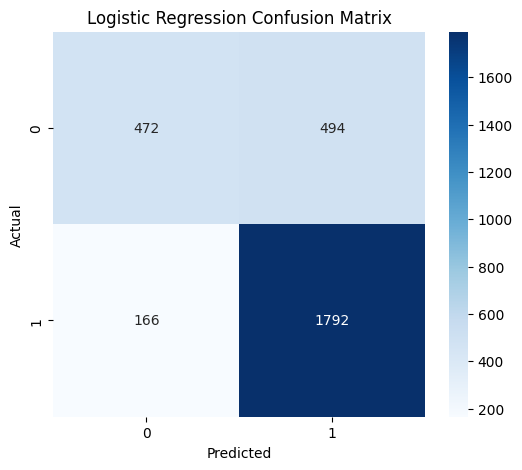

Accuracy : 0.7743
Precision: 0.7839
Recall   : 0.9152
F1-score : 0.8445

==================== Naive Bayes ====================


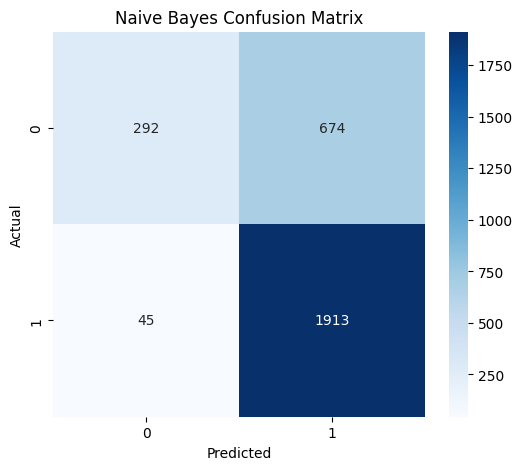

Accuracy : 0.7541
Precision: 0.7395
Recall   : 0.9770
F1-score : 0.8418

==================== Random Forest ====================


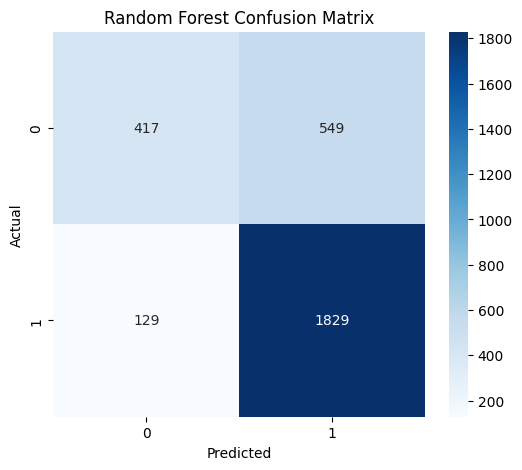

Accuracy : 0.7681
Precision: 0.7691
Recall   : 0.9341
F1-score : 0.8436


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{'='*20} {name} {'='*20}")
    plot_confusion_matrix(y_test, y_pred, labels=[0, 1], title=f"{name} Confusion Matrix")

    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_test, y_pred):.4f}")